# Malaria-Infected RBC Classification Using an Advanced CNN

This notebook is a complete college-project workflow for classifying red blood cell images as **healthy** or **malaria-infected**. The model training, evaluation tables, plots, confusion matrix, heatmaps, ROC/PR curves, error analysis, and Grad-CAM outputs are all kept inside this notebook.

## Dataset Features
- Dataset folder: `cell_images`
- Classes used: `Uninfected` and `Parasitized`
- The duplicate nested folder `cell_images/cell_images` is intentionally ignored to avoid double-counting images.

## Workflow
1. Import libraries and set reproducibility.
2. Collect image paths and audit the dataset.
3. Explore class balance, image size variation, intensity variation, and noise handling.
4. Build a stratified train/validation/test split.
5. Train a compact PyTorch CNN with augmentation, class weighting, and regularization.
6. Evaluate with confusion matrix, metric heatmap, ROC/PR curves, error analysis, and Grad-CAM.
7. Summarize improvement directions for medical validation.


# 1. Library Imports


In [108]:
import os
from pathlib import Path

PROJECT_ROOT_CANDIDATE = Path.cwd()
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "2")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "2")
import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "aiest_mpl_cache"))

import math
import random
import re
import warnings
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFilter
from IPython.display import display, Image as IPyImage

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 180

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Working directory:", Path.cwd())


def show_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=180)
    buffer.seek(0)
    display(IPyImage(data=buffer.getvalue()))
    plt.close(fig)


PyTorch: 2.11.0
Device: cpu
Working directory: /Users/kavaykhurana/Desktop/aiest


# 2. Data Collection


In [109]:
def find_project_root():
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for root in search_roots:
        if (root / "cell_images" / "Parasitized").exists() and (root / "cell_images" / "Uninfected").exists():
            return root
    raise FileNotFoundError("Could not locate the cell_images dataset folder.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "cell_images"

CLASS_MAP = {"Uninfected": 0, "Parasitized": 1}
LABEL_NAMES = {0: "Healthy", 1: "Malaria-Infected"}
IMG_SIZE = (64, 64)
BATCH_SIZE = 16
EPOCHS = 4

# Keep this classroom-friendly. Set to False for a full dataset run.
FAST_RUN = True
IMAGES_PER_CLASS = 500 if FAST_RUN else None
VALIDATION_SCAN_LIMIT = 1400 if FAST_RUN else None

print("Project root:", PROJECT_ROOT)
print("Dataset folder:", DATA_DIR)
print("Fast run:", FAST_RUN)


Project root: /Users/kavaykhurana/Desktop/aiest
Dataset folder: /Users/kavaykhurana/Desktop/aiest/cell_images
Fast run: True


In [110]:
def collect_image_paths(data_dir: Path) -> pd.DataFrame:
    rows = []
    for class_name, label in CLASS_MAP.items():
        class_dir = data_dir / class_name
        files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
        for path in files:
            rows.append(
                {
                    "path": str(path),
                    "filename": path.name,
                    "class_name": class_name,
                    "label": label,
                    "label_name": LABEL_NAMES[label],
                }
            )
    return pd.DataFrame(rows)


image_df = collect_image_paths(DATA_DIR)
print("Images collected:", f"{len(image_df):,}")
print("Columns:", list(image_df.columns))
display(image_df.head())


Images collected: 27,558
Columns: ['path', 'filename', 'class_name', 'label', 'label_name']


,path,filename,class_name,label,label_name
0,/Users/kavaykhurana/Desktop/aiest/cell_images/...,C100P61ThinF_IMG_20150918_144104_cell_128.png,Uninfected,0,Healthy
1,/Users/kavaykhurana/Desktop/aiest/cell_images/...,C100P61ThinF_IMG_20150918_144104_cell_131.png,Uninfected,0,Healthy
2,/Users/kavaykhurana/Desktop/aiest/cell_images/...,C100P61ThinF_IMG_20150918_144104_cell_144.png,Uninfected,0,Healthy
3,/Users/kavaykhurana/Desktop/aiest/cell_images/...,C100P61ThinF_IMG_20150918_144104_cell_21.png,Uninfected,0,Healthy
4,/Users/kavaykhurana/Desktop/aiest/cell_images/...,C100P61ThinF_IMG_20150918_144104_cell_25.png,Uninfected,0,Healthy


In [111]:
class_counts = image_df["class_name"].value_counts().rename_axis("class_name").reset_index(name="image_count")
nested_copy_exists = (DATA_DIR / "cell_images").exists()

print("Class counts from the direct folders:")
display(class_counts)
print("Nested duplicate folder present:", nested_copy_exists)
if nested_copy_exists:
    print("The nested copy is ignored so that the same image is not counted twice.")


Class counts from the direct folders:


,class_name,image_count
0,Uninfected,13779
1,Parasitized,13779


Nested duplicate folder present: True
The nested copy is ignored so that the same image is not counted twice.


# 3. Data Preprocessing & Statistics


In [112]:
def extract_patient_id(filename: str) -> str:
    match = re.search(r"(C\d+P\d+)", filename)
    return match.group(1) if match else "unknown"


image_df["patient_id"] = image_df["filename"].apply(extract_patient_id)
image_df["is_duplicate_filename"] = image_df.duplicated("filename", keep=False)

if VALIDATION_SCAN_LIMIT is None:
    scan_df = image_df.copy()
else:
    scan_per_class = max(1, VALIDATION_SCAN_LIMIT // image_df["label"].nunique())
    scan_df = (
        image_df.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(min(scan_per_class, len(x)), random_state=SEED))
        .reset_index(drop=True)
    )

validation_rows = []
for path in scan_df["path"]:
    record = {"path": path, "readable": True, "width": np.nan, "height": np.nan, "mode": None}
    try:
        with Image.open(path) as img:
            record["width"], record["height"] = img.size
            record["mode"] = img.mode
    except Exception:
        record["readable"] = False
    validation_rows.append(record)

validation_df = pd.DataFrame(validation_rows)
print("Images checked:", len(validation_df))
print("Unreadable images in checked set:", int((~validation_df["readable"]).sum()))
display(validation_df.head())


Images checked: 1400
Unreadable images in checked set: 0


,path,readable,width,height,mode
0,/Users/kavaykhurana/Desktop/aiest/cell_images/...,True,169,205,RGB
1,/Users/kavaykhurana/Desktop/aiest/cell_images/...,True,127,142,RGB
2,/Users/kavaykhurana/Desktop/aiest/cell_images/...,True,124,133,RGB
3,/Users/kavaykhurana/Desktop/aiest/cell_images/...,True,97,85,RGB
4,/Users/kavaykhurana/Desktop/aiest/cell_images/...,True,106,139,RGB


## Dataset Statistics


In [113]:
size_summary = validation_df[["width", "height"]].describe().round(2)
patient_summary = (
    image_df.groupby(["label_name"])["patient_id"]
    .nunique()
    .rename("unique_patient_or_slide_ids")
    .reset_index()
)

print("Image size summary from checked images:")
display(size_summary)
print("Identifier summary:")
display(patient_summary)
print("Duplicate filenames in direct folders:", int(image_df["is_duplicate_filename"].sum()))


Image size summary from checked images:


,width,height
count,1400.00,1400.00
mean,132.11,132.86
std,20.65,22.24
min,58.00,52.00
25%,118.00,118.00
50%,130.00,130.00
75%,142.00,145.00
max,256.00,247.00


Identifier summary:


,label_name,unique_patient_or_slide_ids
0,Healthy,149
1,Malaria-Infected,149


Duplicate filenames in direct folders: 0


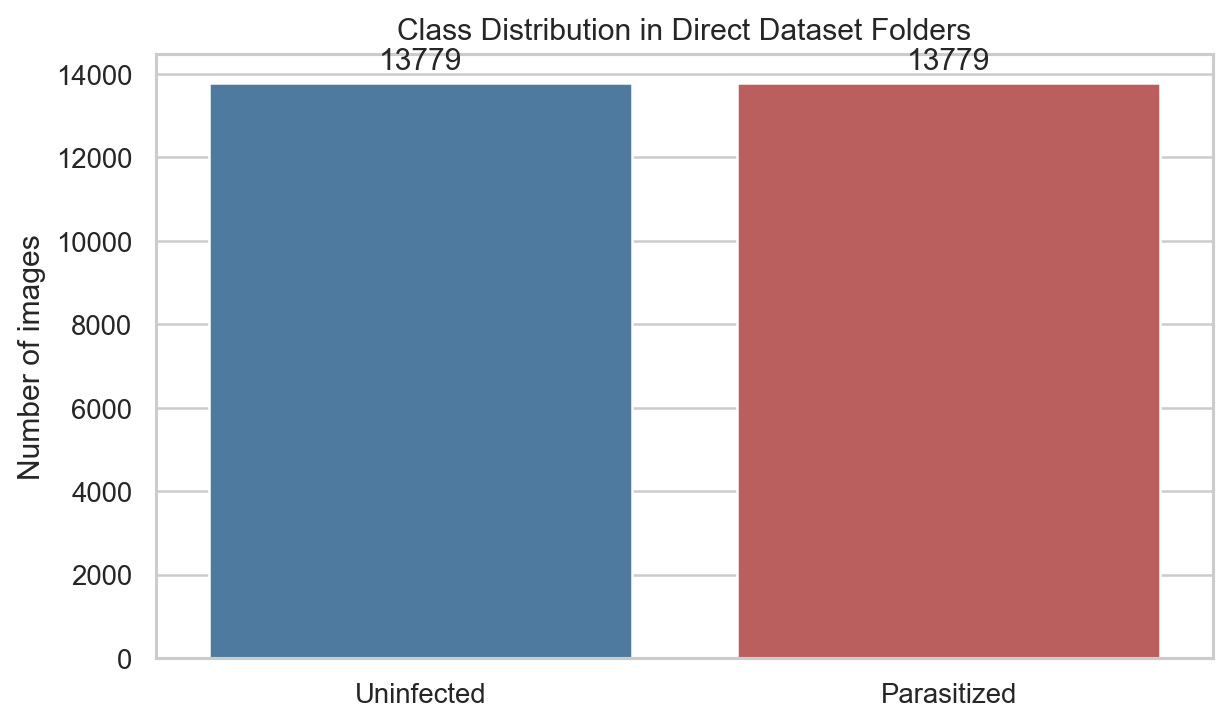

In [114]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.barplot(data=class_counts, x="class_name", y="image_count", palette=["#3f7cac", "#c94f4f"], ax=ax)
ax.set_title("Class Distribution in Direct Dataset Folders")
ax.set_xlabel("")
ax.set_ylabel("Number of images")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
fig.tight_layout()
show_figure(fig)



# 4. Exploratory Data Analysis (EDA)


## Cell Image Samples


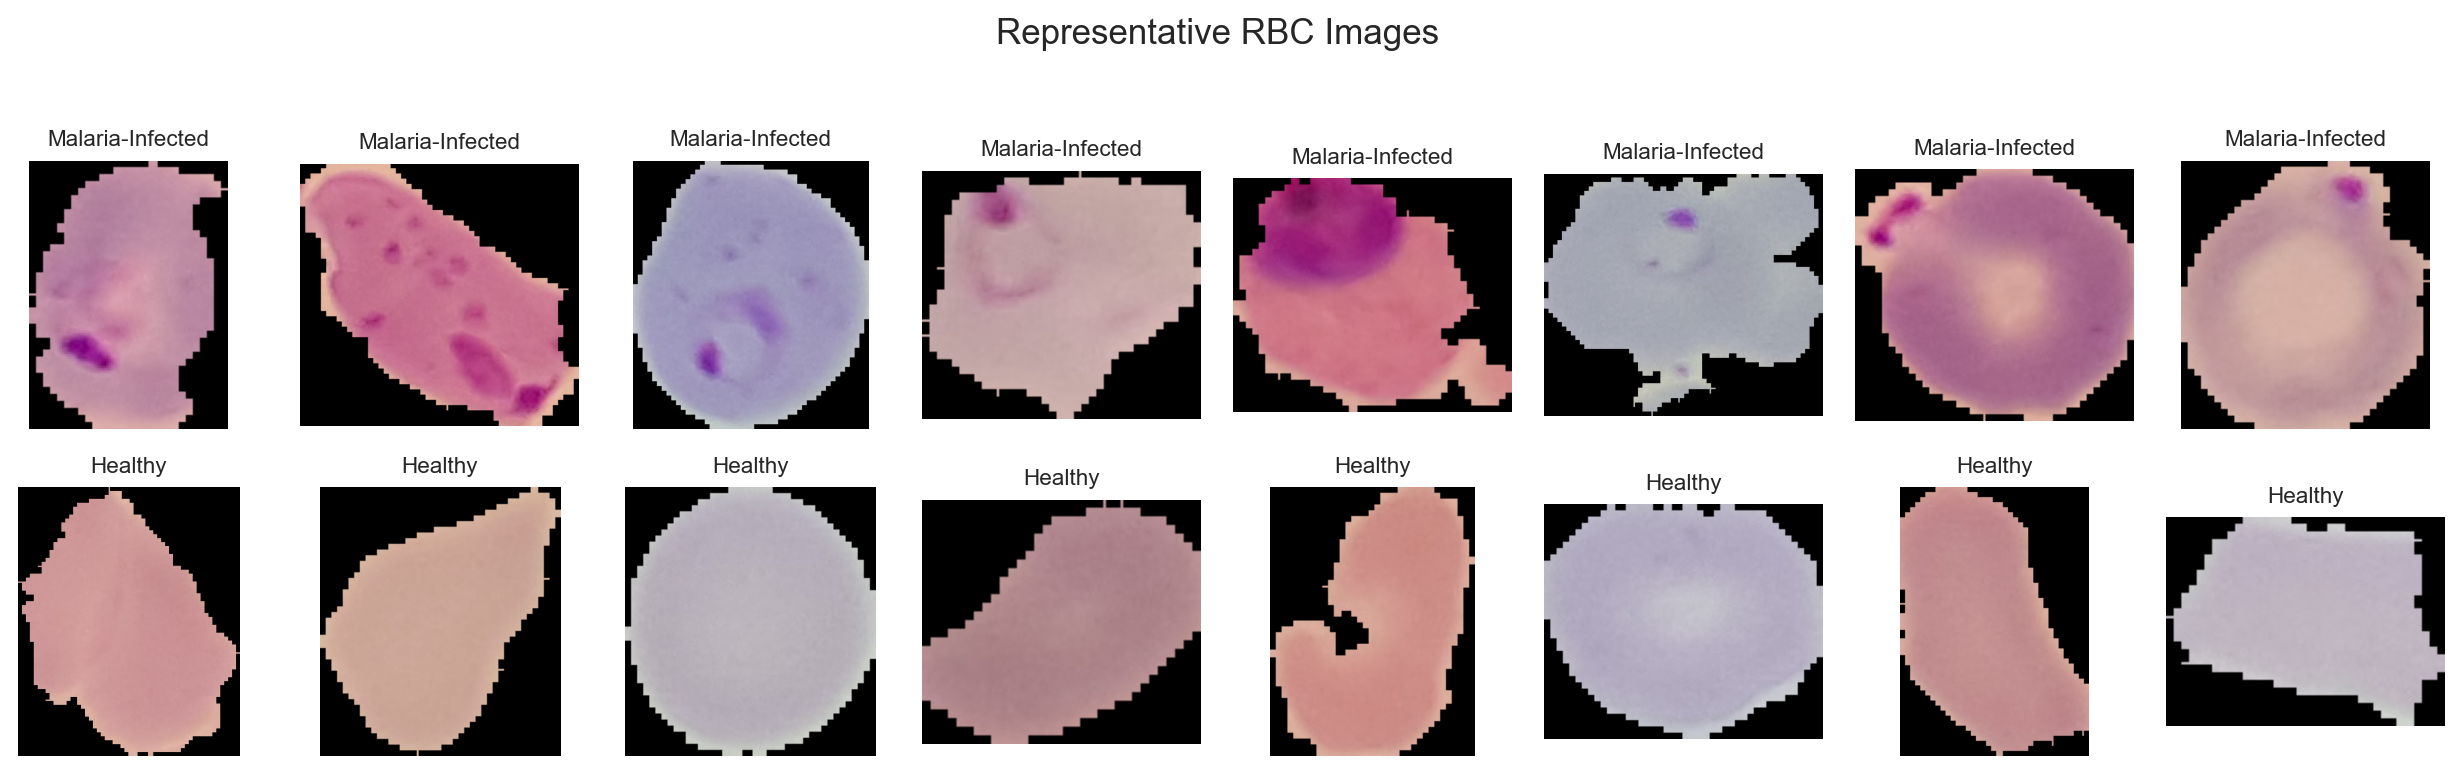

In [115]:
sample_per_class = 8
sample_df = (
    image_df.groupby("class_name", group_keys=False)
    .apply(lambda x: x.sample(sample_per_class, random_state=SEED))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, sample_per_class, figsize=(14, 4.2))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    with Image.open(row["path"]) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(row["label_name"], fontsize=9)
    ax.axis("off")
fig.suptitle("Representative RBC Images", y=1.02, fontsize=14)
fig.tight_layout()
show_figure(fig)



## Image Size Distribution


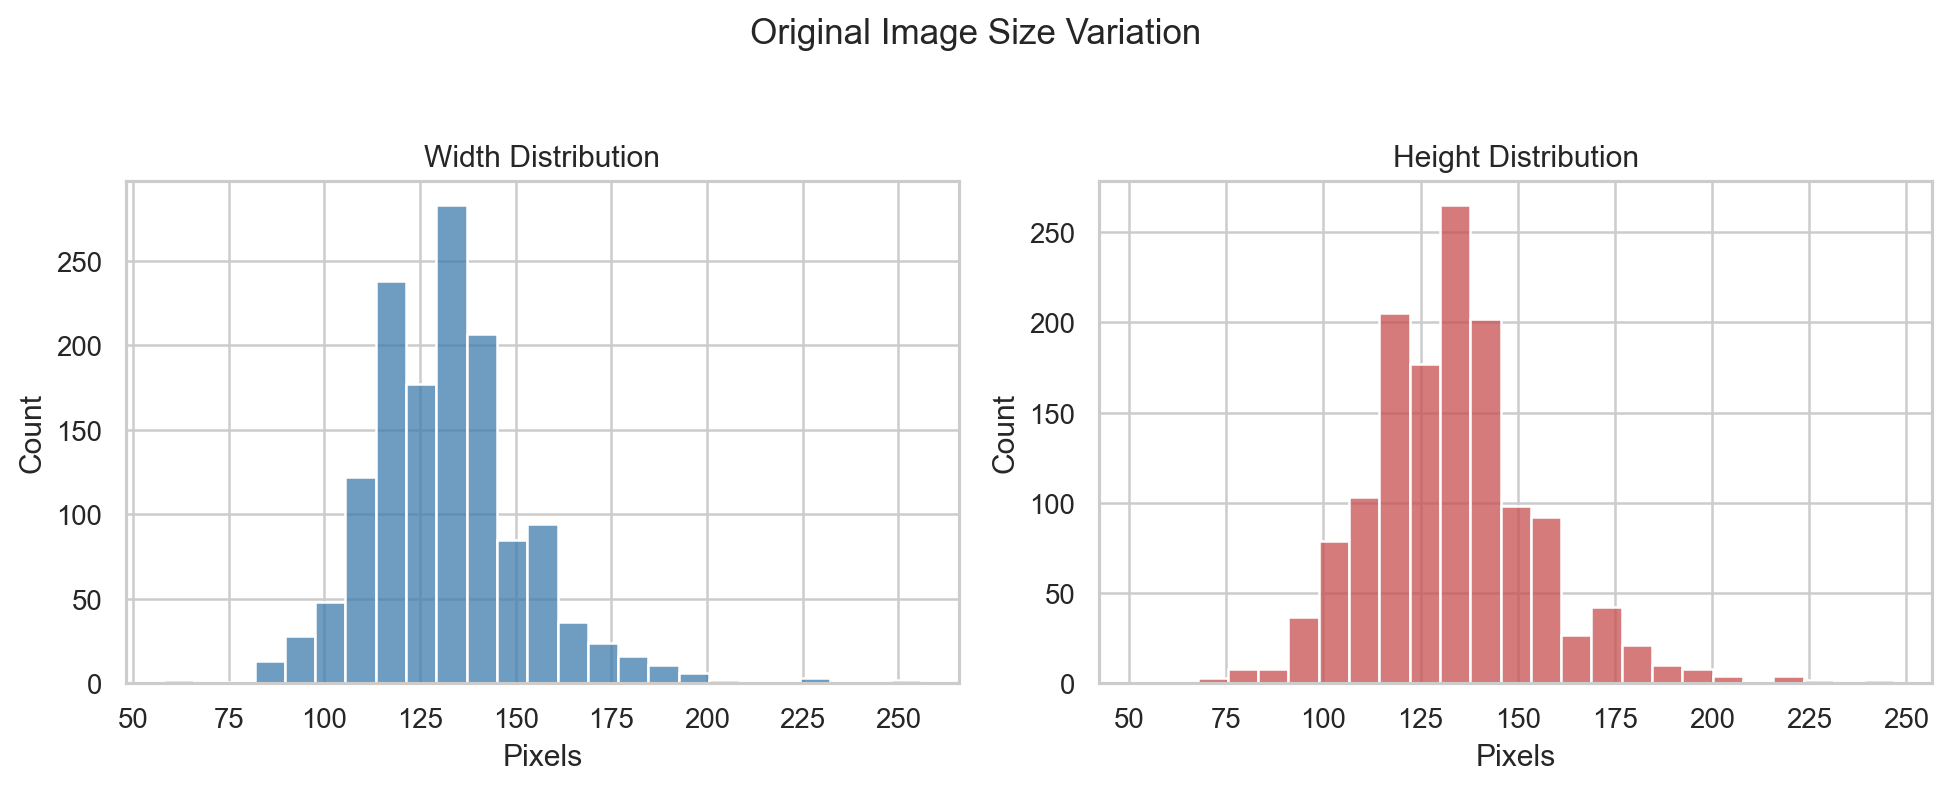

In [116]:
readable_sizes = validation_df[validation_df["readable"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.histplot(readable_sizes["width"], bins=25, color="#3f7cac", ax=axes[0])
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Pixels")

sns.histplot(readable_sizes["height"], bins=25, color="#c94f4f", ax=axes[1])
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Pixels")

fig.suptitle("Original Image Size Variation", y=1.04, fontsize=14)
fig.tight_layout()
show_figure(fig)



## Color and Intensity Profile


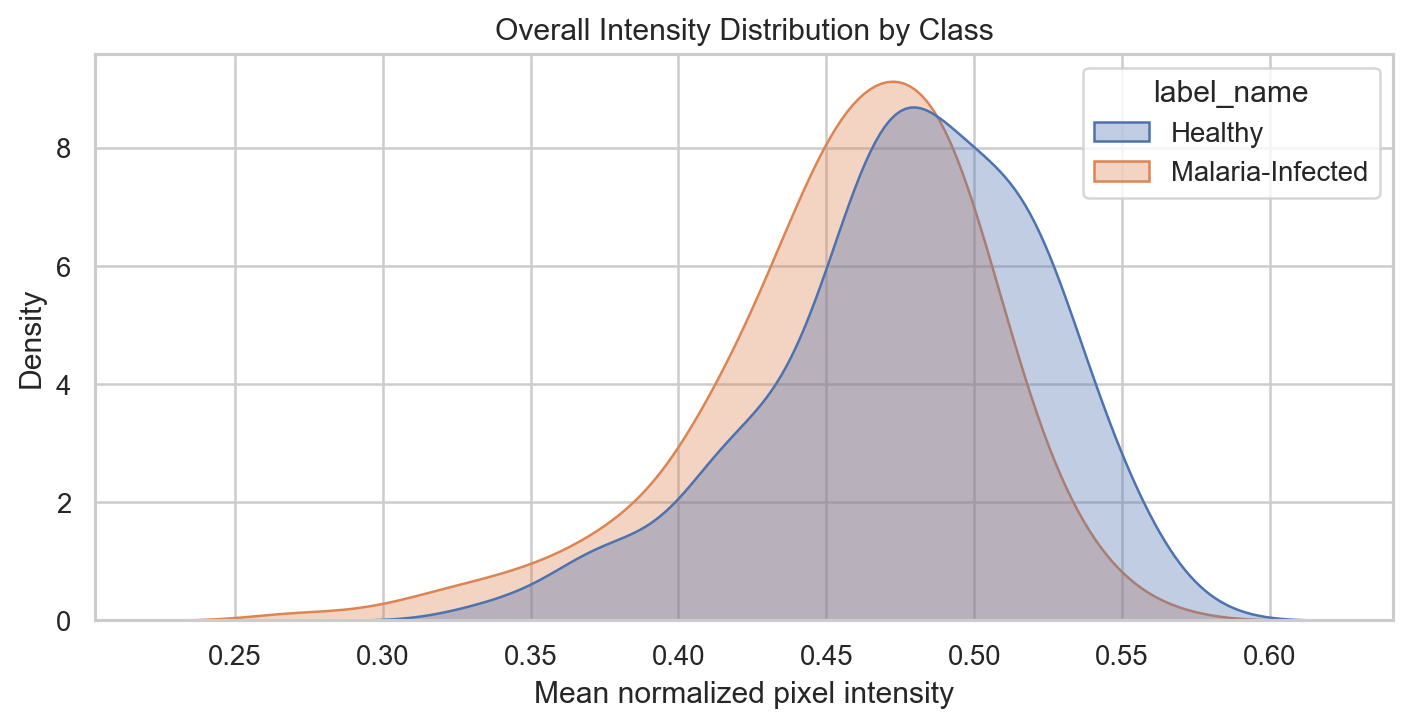

,mean_red,mean_green,mean_blue,overall_intensity
label_name,,,,
Healthy,0.5293,0.4382,0.4634,0.4769
Malaria-Infected,0.5296,0.4013,0.4378,0.4562


In [117]:
intensity_records = []
intensity_per_class = max(1, min(500, len(image_df)) // image_df["label"].nunique())
intensity_sample = (
    image_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(intensity_per_class, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

for _, row in intensity_sample.iterrows():
    with Image.open(row["path"]) as img:
        arr = np.asarray(img.convert("RGB").resize(IMG_SIZE), dtype=np.float32) / 255.0
    intensity_records.append(
        {
            "label_name": row["label_name"],
            "mean_red": arr[:, :, 0].mean(),
            "mean_green": arr[:, :, 1].mean(),
            "mean_blue": arr[:, :, 2].mean(),
            "overall_intensity": arr.mean(),
        }
    )

intensity_df = pd.DataFrame(intensity_records)
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.kdeplot(data=intensity_df, x="overall_intensity", hue="label_name", fill=True, common_norm=False, alpha=0.35, ax=ax)
ax.set_title("Overall Intensity Distribution by Class")
ax.set_xlabel("Mean normalized pixel intensity")
fig.tight_layout()
show_figure(fig)

display(intensity_df.groupby("label_name").mean(numeric_only=True).round(4))


## Noise Handling Preview


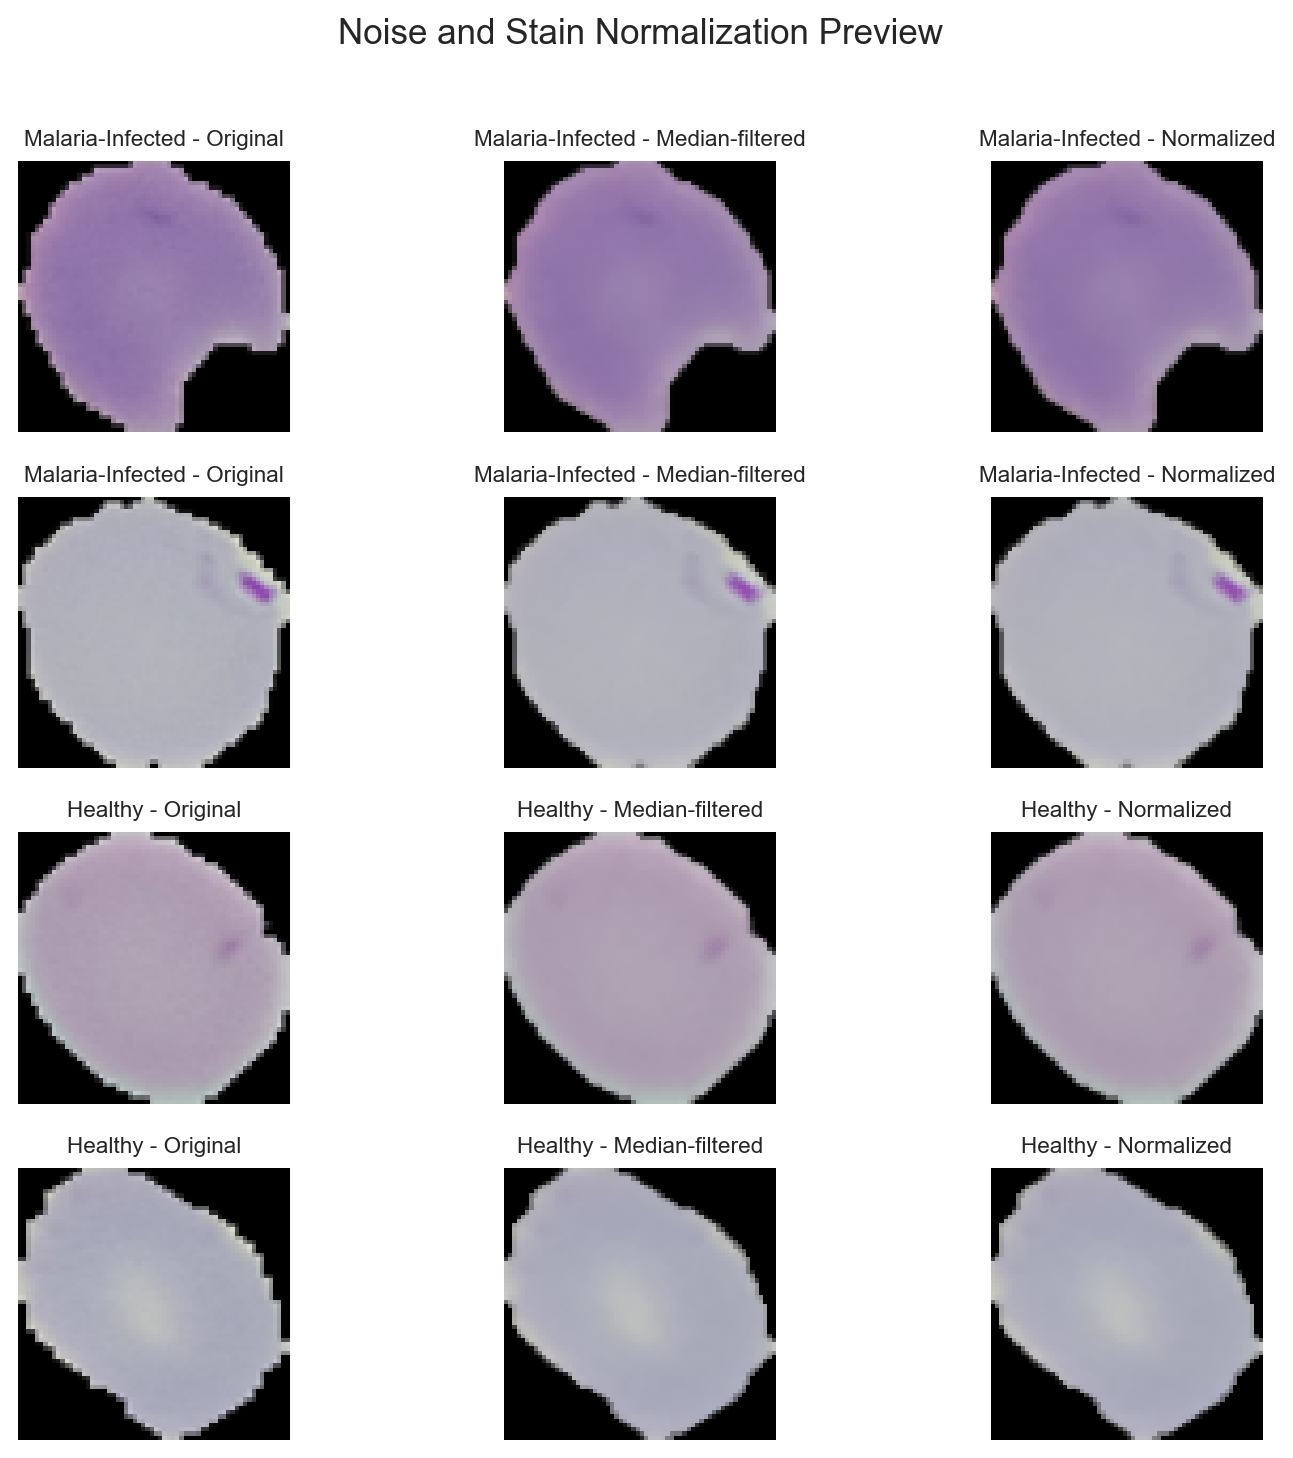

In [118]:
noise_sample = (
    image_df.groupby("class_name", group_keys=False)
    .apply(lambda x: x.sample(2, random_state=SEED + 7))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(len(noise_sample), 3, figsize=(9, 8))
for row_idx, (_, row) in enumerate(noise_sample.iterrows()):
    with Image.open(row["path"]) as img:
        original = img.convert("RGB").resize(IMG_SIZE)
        denoised = original.filter(ImageFilter.MedianFilter(size=3))
        normalized = np.asarray(denoised, dtype=np.float32) / 255.0

    panels = [original, denoised, normalized]
    titles = ["Original", "Median-filtered", "Normalized"]
    for col_idx, (panel, title) in enumerate(zip(panels, titles)):
        axes[row_idx, col_idx].imshow(panel)
        axes[row_idx, col_idx].set_title(f"{row['label_name']} - {title}", fontsize=9)
        axes[row_idx, col_idx].axis("off")

fig.suptitle("Noise and Stain Normalization Preview", y=1.01, fontsize=14)
fig.tight_layout()
show_figure(fig)



## Class Balance and Patient Identifier Check


In [119]:
balance_table = image_df.groupby("label_name").agg(
    images=("path", "count"),
    unique_ids=("patient_id", "nunique"),
)
balance_table["image_share"] = (balance_table["images"] / balance_table["images"].sum()).round(4)
display(balance_table)

print(
    "The source folders are balanced in this copy, but the training code still computes class weights "
    "so the pipeline remains valid for imbalanced updates of the dataset."
)


,images,unique_ids,image_share
label_name,,,
Healthy,13779,149,0.5
Malaria-Infected,13779,149,0.5


The source folders are balanced in this copy, but the training code still computes class weights so the pipeline remains valid for imbalanced updates of the dataset.


# 5. Feature Engineering


## Train, Validation, and Test Split


In [120]:
# Rebuild the dataset table locally in this cell.
rows = []
for class_name, label_id in CLASS_MAP.items():
    class_dir = DATA_DIR / class_name
    image_files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
    for path in image_files:
        rows.append(
            {
                "path": str(path),
                "filename": path.name,
                "class_name": class_name,
                "label": int(label_id),
                "label_name": LABEL_NAMES[int(label_id)],
            }
        )

image_df = pd.DataFrame(rows, columns=["path", "filename", "class_name", "label", "label_name"])
if image_df.empty:
    raise ValueError("No images were found in the direct Parasitized and Uninfected folders.")

required_columns = {"path", "filename", "class_name", "label", "label_name"}
missing_columns = required_columns.difference(image_df.columns)
if missing_columns:
    raise ValueError(f"image_df is missing required columns: {sorted(missing_columns)}")

if FAST_RUN:
    sampled_parts = []
    for label_id in sorted(image_df["label"].unique()):
        class_df = image_df.loc[image_df["label"].eq(label_id)].copy()
        sample_n = min(IMAGES_PER_CLASS, len(class_df))
        sampled_parts.append(class_df.sample(sample_n, random_state=SEED))
    working_df = pd.concat(sampled_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    working_df = image_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

if "label" not in working_df.columns:
    raise ValueError("working_df has no label column after sampling. Check the dataset table construction above.")

train_df, holdout_df = train_test_split(
    working_df,
    test_size=0.30,
    random_state=SEED,
    stratify=working_df.loc[:, "label"],
)
val_df, test_df = train_test_split(
    holdout_df,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout_df.loc[:, "label"],
)

split_summary = pd.concat(
    {
        "train": train_df["label_name"].value_counts(),
        "validation": val_df["label_name"].value_counts(),
        "test": test_df["label_name"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

print("Working images:", f"{len(working_df):,}")
display(split_summary)


Working images: 1,000


,train,validation,test
label_name,,,
Malaria-Infected,350,75,75
Healthy,350,75,75


## Class Weights for Imbalance


In [121]:
classes = np.array(sorted(train_df["label"].unique()))
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label"])
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}

class_weight_table = pd.DataFrame(
    {
        "class": [LABEL_NAMES[int(cls)] for cls in classes],
        "label": classes,
        "class_weight": weights.round(4),
    }
)
display(class_weight_table)


,class,label,class_weight
0,Healthy,0,1.0
1,Malaria-Infected,1,1.0


## Image Tensor Pipeline


In [122]:
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=18),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.90, 1.12)),
        transforms.ColorJitter(brightness=0.14, contrast=0.18, saturation=0.10),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.4, 2.2), value="random"),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
    ]
)


class CellImageDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].astype(str).tolist()
        self.labels = df["label"].astype("float32").values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as img:
            image = img.convert("RGB")
        return self.transform(image), torch.tensor(self.labels[idx], dtype=torch.float32)


train_dataset = CellImageDataset(train_df, train_transform)
val_dataset = CellImageDataset(val_df, eval_transform)
test_dataset = CellImageDataset(test_df, eval_transform)

sample_weights = train_df["label"].map(class_weight).astype("float32").values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch_images, batch_labels = next(iter(train_loader))
print("Batch image tensor:", batch_images.shape)
print("Batch label tensor:", batch_labels.shape)


Batch image tensor: torch.Size([16, 3, 64, 64])
Batch label tensor: torch.Size([16])


## Augmentation Strategy


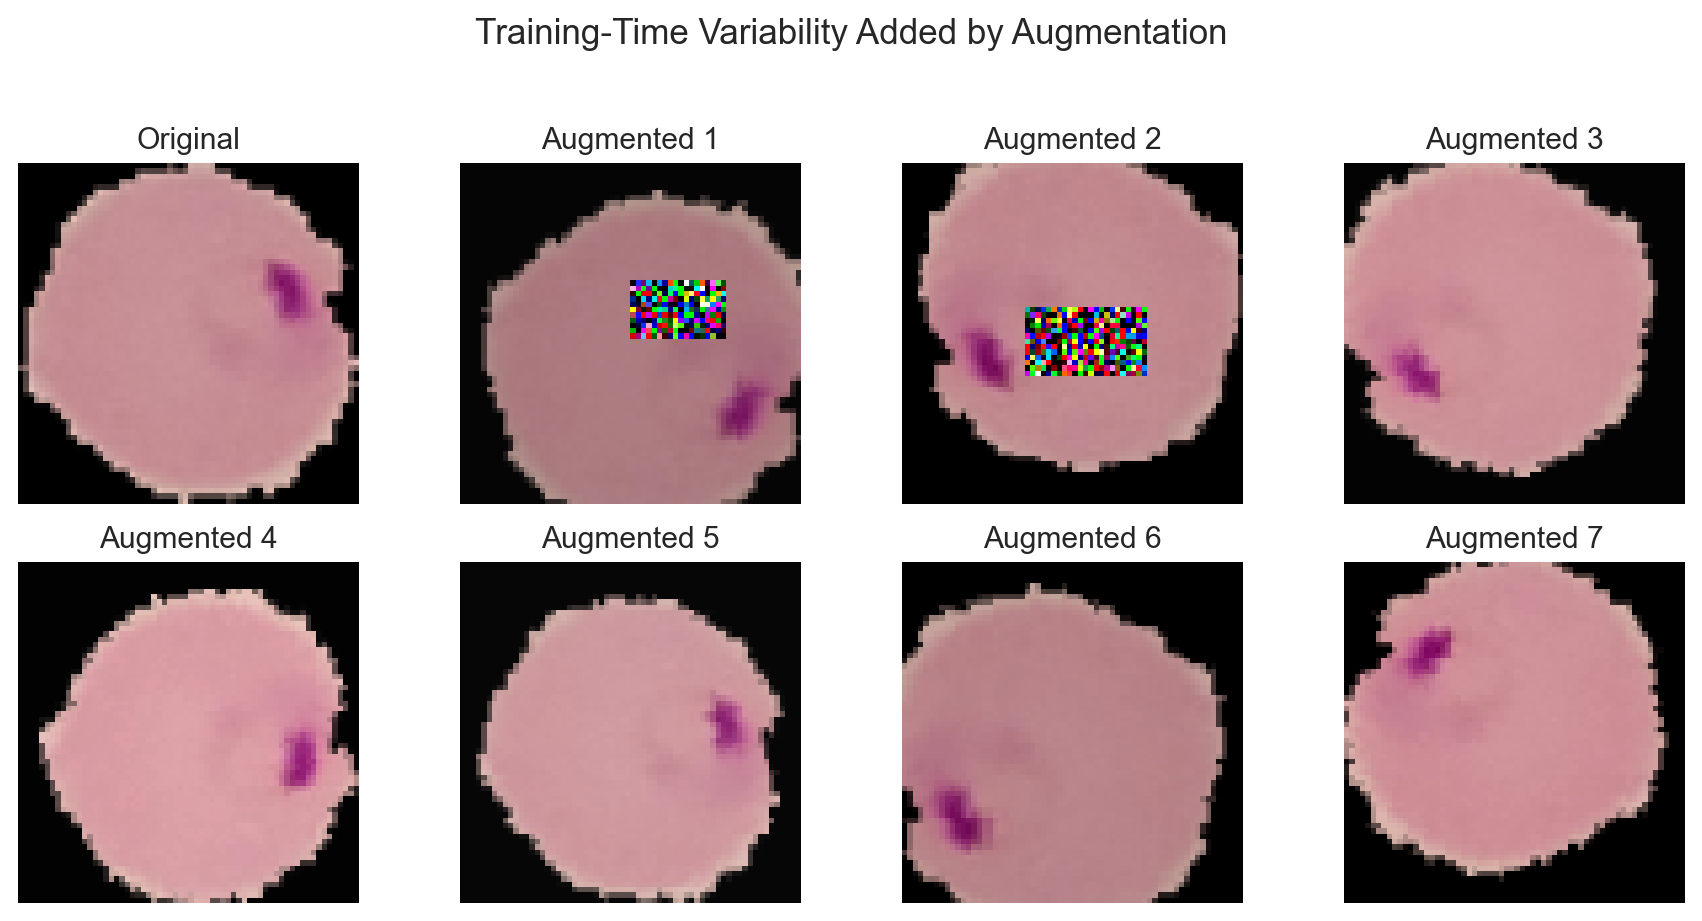

In [123]:
preview_path = train_df.iloc[0]["path"]
with Image.open(preview_path) as img:
    preview_image = img.convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()
axes[0].imshow(preview_image.resize(IMG_SIZE))
axes[0].set_title("Original")
axes[0].axis("off")
for idx in range(1, 8):
    augmented = train_transform(preview_image)
    axes[idx].imshow(augmented.permute(1, 2, 0).numpy().clip(0, 1))
    axes[idx].set_title(f"Augmented {idx}")
    axes[idx].axis("off")
fig.suptitle("Training-Time Variability Added by Augmentation", y=1.02, fontsize=14)
fig.tight_layout()
show_figure(fig)



# 6. Model Selection & Training


## Advanced CNN Architecture


In [124]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=False),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
        )

    def forward(self, x):
        return self.block(x)


class AdvancedMalariaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 16, 0.10),
            ConvBlock(16, 32, 0.15),
            ConvBlock(32, 64, 0.20),
        )
        self.last_conv = nn.Conv2d(64, 96, kernel_size=3, padding=1, bias=False)
        self.last_bn = nn.BatchNorm2d(96)
        self.last_relu = nn.ReLU(inplace=False)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64),
            nn.ReLU(inplace=False),
            nn.Dropout(0.35),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.last_conv(x)
        x = self.last_bn(x)
        x = self.last_relu(x)
        x = self.pool(x)
        return self.classifier(x).squeeze(1)


model = AdvancedMalariaCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")


AdvancedMalariaCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4)

## Training Callbacks and Hyperparameters


In [125]:
positive_count = int((train_df["label"] == 1).sum())
negative_count = int((train_df["label"] == 0).sum())
pos_weight_value = negative_count / max(positive_count, 1)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.45, patience=1)


hyperparameters = pd.DataFrame(
    [
        ("image_size", f"{IMG_SIZE[0]} x {IMG_SIZE[1]}"),
        ("batch_size", BATCH_SIZE),
        ("epochs_planned", EPOCHS),
        ("optimizer", "AdamW, learning rate 1e-3, weight decay 1e-4"),
        ("loss", "BCEWithLogitsLoss with positive-class weighting"),
        ("imbalance_control", "class weights + weighted random sampler"),
        ("noise_control", "median-filter audit + RandomErasing augmentation"),
        ("regularization", "BatchNorm, Dropout, weight decay, augmentation"),
    ],
    columns=["setting", "value"],
)
display(hyperparameters)


,setting,value
0,image_size,64 x 64
1,batch_size,16
2,epochs_planned,4
3,optimizer,"AdamW, learning rate 1e-3, weight decay 1e-4"
4,loss,BCEWithLogitsLoss with positive-class weighting
5,imbalance_control,class weights + weighted random sampler
6,noise_control,median-filter audit + RandomErasing augmentation
7,regularization,"BatchNorm, Dropout, weight decay, augmentation"


## Model Training

The cell below trains the CNN, prints train and validation metrics for every epoch, and keeps the best validation-AUC weights in memory for final testing.


In [126]:
def run_epoch(model, loader, training):
    model.train(training)
    total_loss = 0.0
    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())

    avg_loss = total_loss / len(loader.dataset)
    probs = np.array(all_probs)
    labels = np.array(all_labels)
    preds = (probs >= 0.5).astype(int)
    return {
        "loss": avg_loss,
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "auc": roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else np.nan,
    }


history_records = []
best_val_auc = -np.inf
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, training=True)
    val_metrics = run_epoch(model, val_loader, training=False)
    scheduler.step(val_metrics["loss"])

    history_records.append(
        {
            "epoch": epoch,
            "loss": train_metrics["loss"],
            "accuracy": train_metrics["accuracy"],
            "precision": train_metrics["precision"],
            "recall": train_metrics["recall"],
            "auc": train_metrics["auc"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_auc": val_metrics["auc"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )

    print(
        f"Epoch {epoch}/{EPOCHS} - "
        f"loss: {train_metrics['loss']:.4f}, acc: {train_metrics['accuracy']:.3f}, "
        f"val_loss: {val_metrics['loss']:.4f}, val_acc: {val_metrics['accuracy']:.3f}, "
        f"val_auc: {val_metrics['auc']:.3f}"
    )

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation AUC:", round(float(best_val_auc), 4))
print("Model stays in notebook memory; no checkpoint file is saved.")


Epoch 1/4 - loss: 0.6676, acc: 0.606, val_loss: 0.6642, val_acc: 0.600, val_auc: 0.684
Epoch 2/4 - loss: 0.6843, acc: 0.599, val_loss: 0.6679, val_acc: 0.600, val_auc: 0.727
Epoch 3/4 - loss: 0.6180, acc: 0.663, val_loss: 0.5683, val_acc: 0.793, val_auc: 0.865
Epoch 4/4 - loss: 0.4847, acc: 0.797, val_loss: 0.3041, val_acc: 0.967, val_auc: 0.992
Best validation AUC: 0.9918
Model stays in notebook memory; no checkpoint file is saved.


In [127]:
history_df = pd.DataFrame(history_records).set_index("epoch")
display(history_df.round(4))


,loss,accuracy,precision,recall,auc,val_loss,val_accuracy,val_precision,val_recall,val_auc,learning_rate
epoch,,,,,,,,,,,
1,0.6676,0.6057,0.6818,0.4213,0.6320,0.6642,0.6000,0.8571,0.2400,0.6843,0.001
2,0.6843,0.5986,0.6092,0.5044,0.6149,0.6679,0.6000,0.8947,0.2267,0.7273,0.001
3,0.6180,0.6629,0.7327,0.4718,0.7508,0.5683,0.7933,0.8929,0.6667,0.8651,0.001
4,0.4847,0.7971,0.8135,0.7666,0.8623,0.3041,0.9667,0.9605,0.9733,0.9918,0.001


# 7. Model Evaluation


## Training Curves


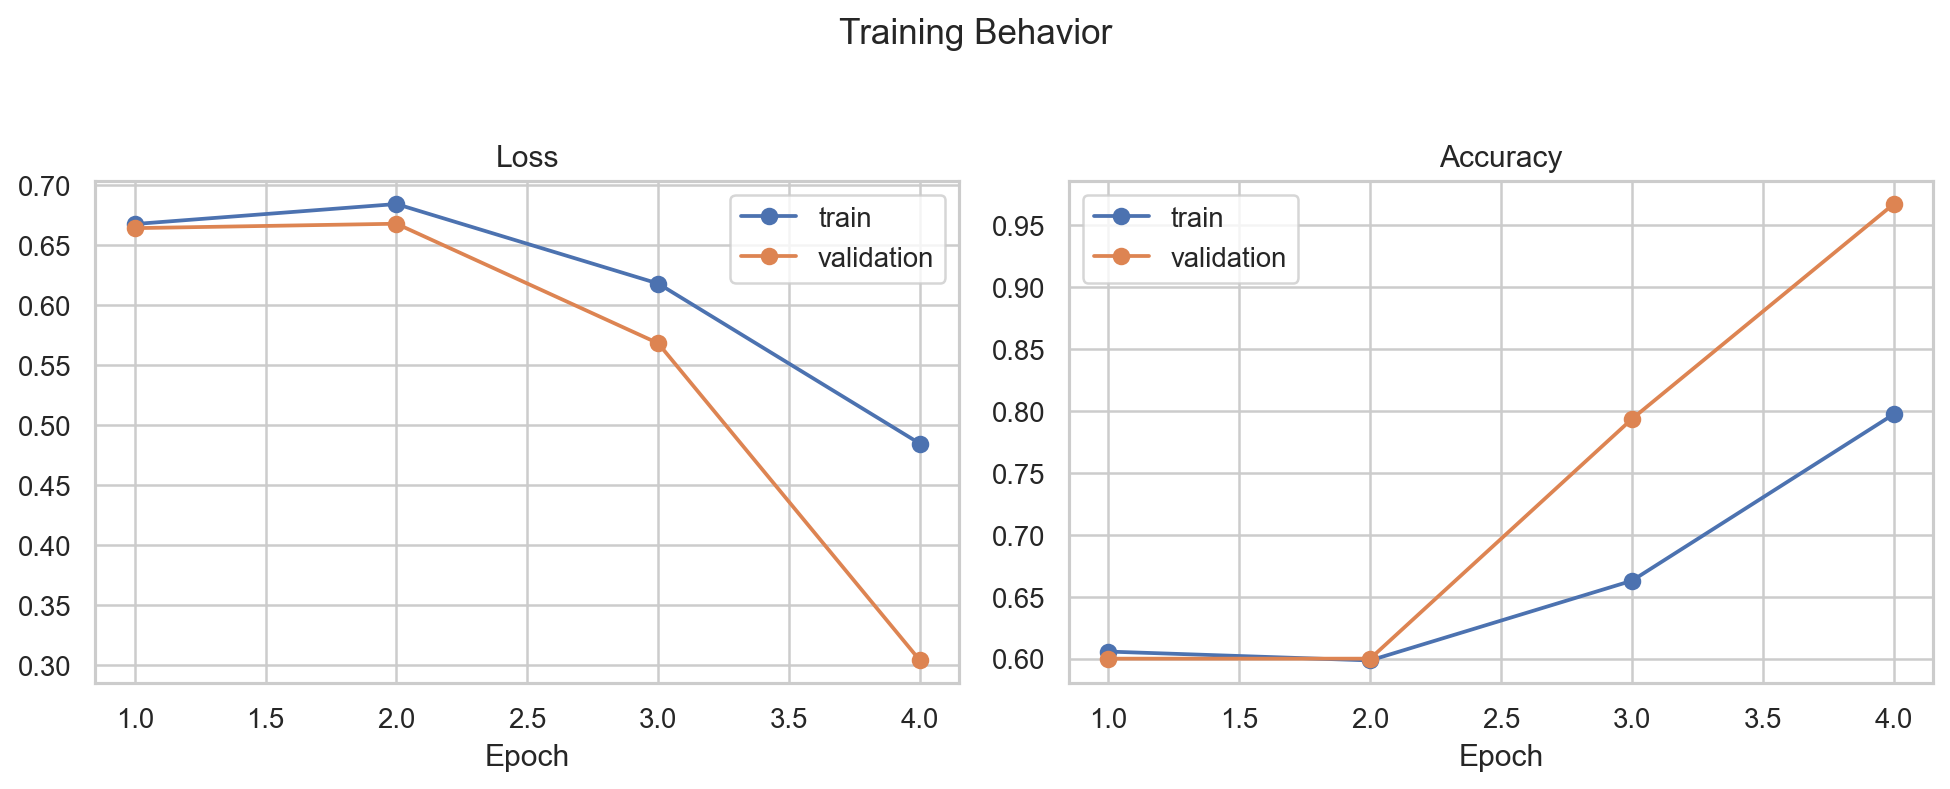

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(history_df.index, history_df["loss"], marker="o", label="train")
axes[0].plot(history_df.index, history_df["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df.index, history_df["accuracy"], marker="o", label="train")
axes[1].plot(history_df.index, history_df["val_accuracy"], marker="o", label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

fig.suptitle("Training Behavior", y=1.04, fontsize=14)
fig.tight_layout()
show_figure(fig)



## Test Set Performance


In [129]:
def predict_loader(model, loader):
    model.eval()
    probs = []
    labels = []
    paths = []
    offset = 0
    with torch.no_grad():
        for images, batch_labels in loader:
            images = images.to(DEVICE)
            logits = model(images)
            batch_probs = torch.sigmoid(logits).cpu().numpy()
            probs.extend(batch_probs.tolist())
            labels.extend(batch_labels.numpy().astype(int).tolist())
            batch_size = len(batch_labels)
            paths.extend(test_df.iloc[offset : offset + batch_size]["path"].tolist())
            offset += batch_size
    return np.array(probs), np.array(labels), paths


test_probs, y_true, test_paths_ordered = predict_loader(model, test_loader)
y_pred = (test_probs >= 0.50).astype(int)

metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "precision": float(precision_score(y_true, y_pred, zero_division=0)),
    "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_true, test_probs)),
    "average_precision": float(average_precision_score(y_true, test_probs)),
    "test_images": int(len(test_df)),
    "threshold": 0.50,
    "fast_run": bool(FAST_RUN),
    "working_images": int(len(working_df)),
}

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Malaria-Infected"],
    output_dict=True,
    zero_division=0,
)


display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}).round(4))
print(classification_report(y_true, y_pred, target_names=["Healthy", "Malaria-Infected"], zero_division=0))


,value
accuracy,0.933333
precision,0.922078
recall,0.946667
f1_score,0.934211
roc_auc,0.982578
average_precision,0.985621
test_images,150
threshold,0.5
fast_run,True
working_images,1000


                  precision    recall  f1-score   support

         Healthy       0.95      0.92      0.93        75
Malaria-Infected       0.92      0.95      0.93        75

        accuracy                           0.93       150
       macro avg       0.93      0.93      0.93       150
    weighted avg       0.93      0.93      0.93       150



## Confusion Matrix


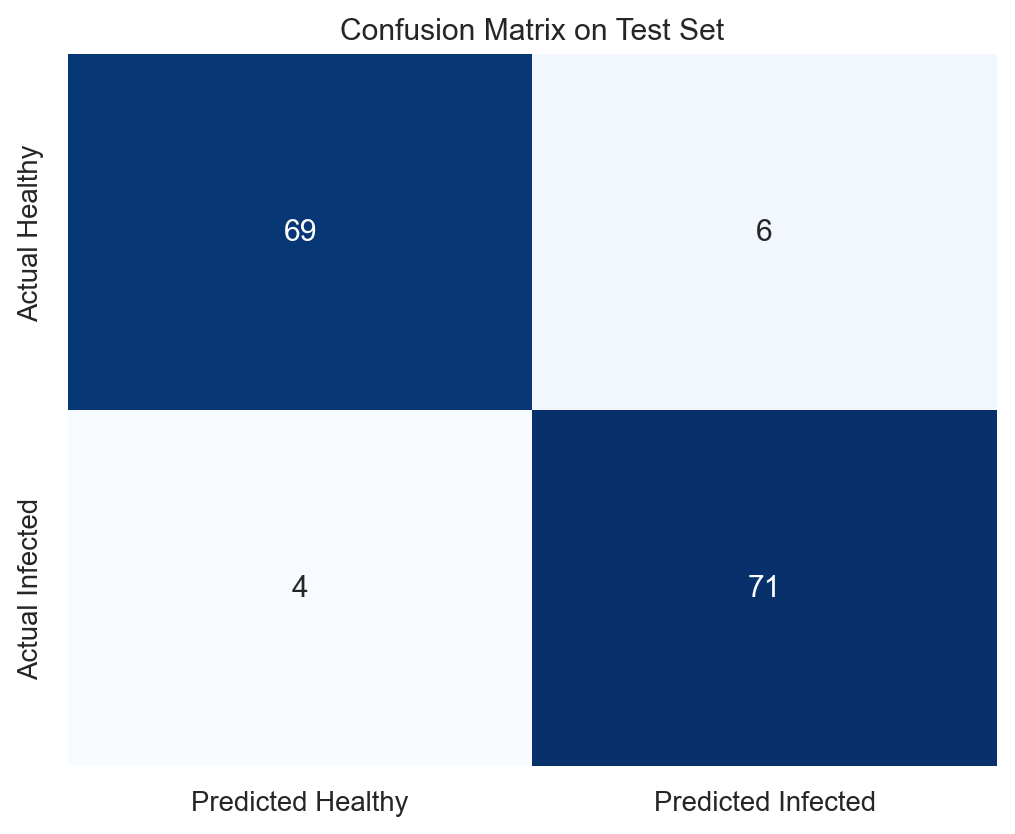

In [130]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5.8, 4.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Healthy", "Predicted Infected"],
    yticklabels=["Actual Healthy", "Actual Infected"],
    cbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix on Test Set")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
show_figure(fig)



## Classification Report Heatmap


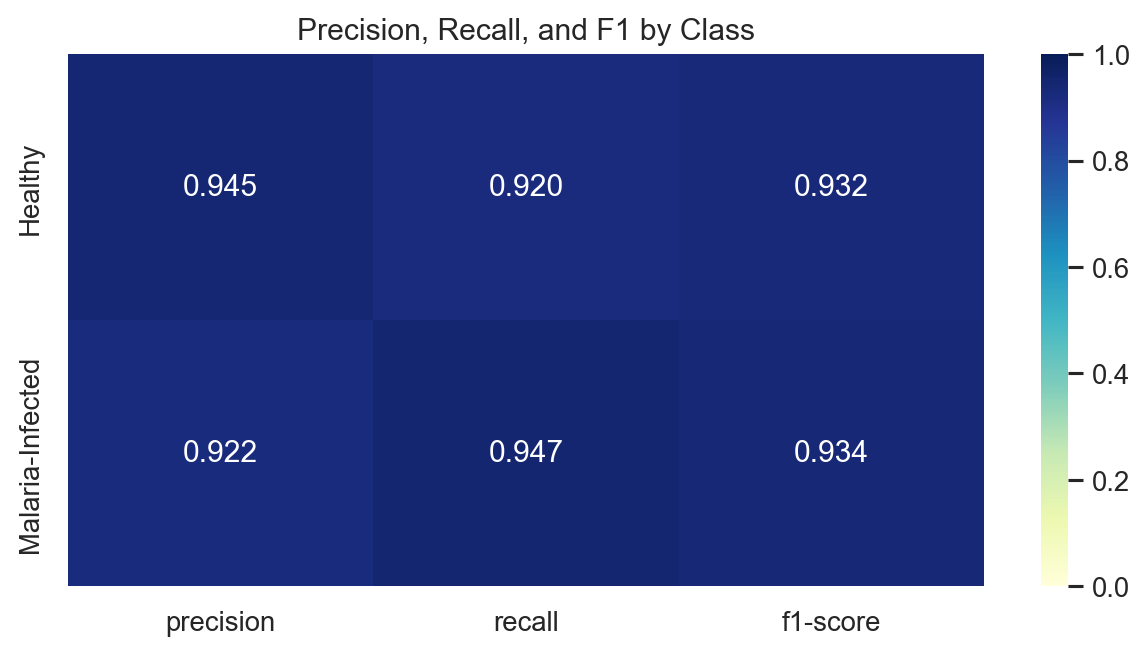

In [131]:
report_df = pd.DataFrame(report_dict).T
report_heatmap_df = report_df.loc[["Healthy", "Malaria-Infected"], ["precision", "recall", "f1-score"]]

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.heatmap(report_heatmap_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", ax=ax)
ax.set_title("Precision, Recall, and F1 by Class")
fig.tight_layout()
show_figure(fig)



## ROC and Precision-Recall Curves


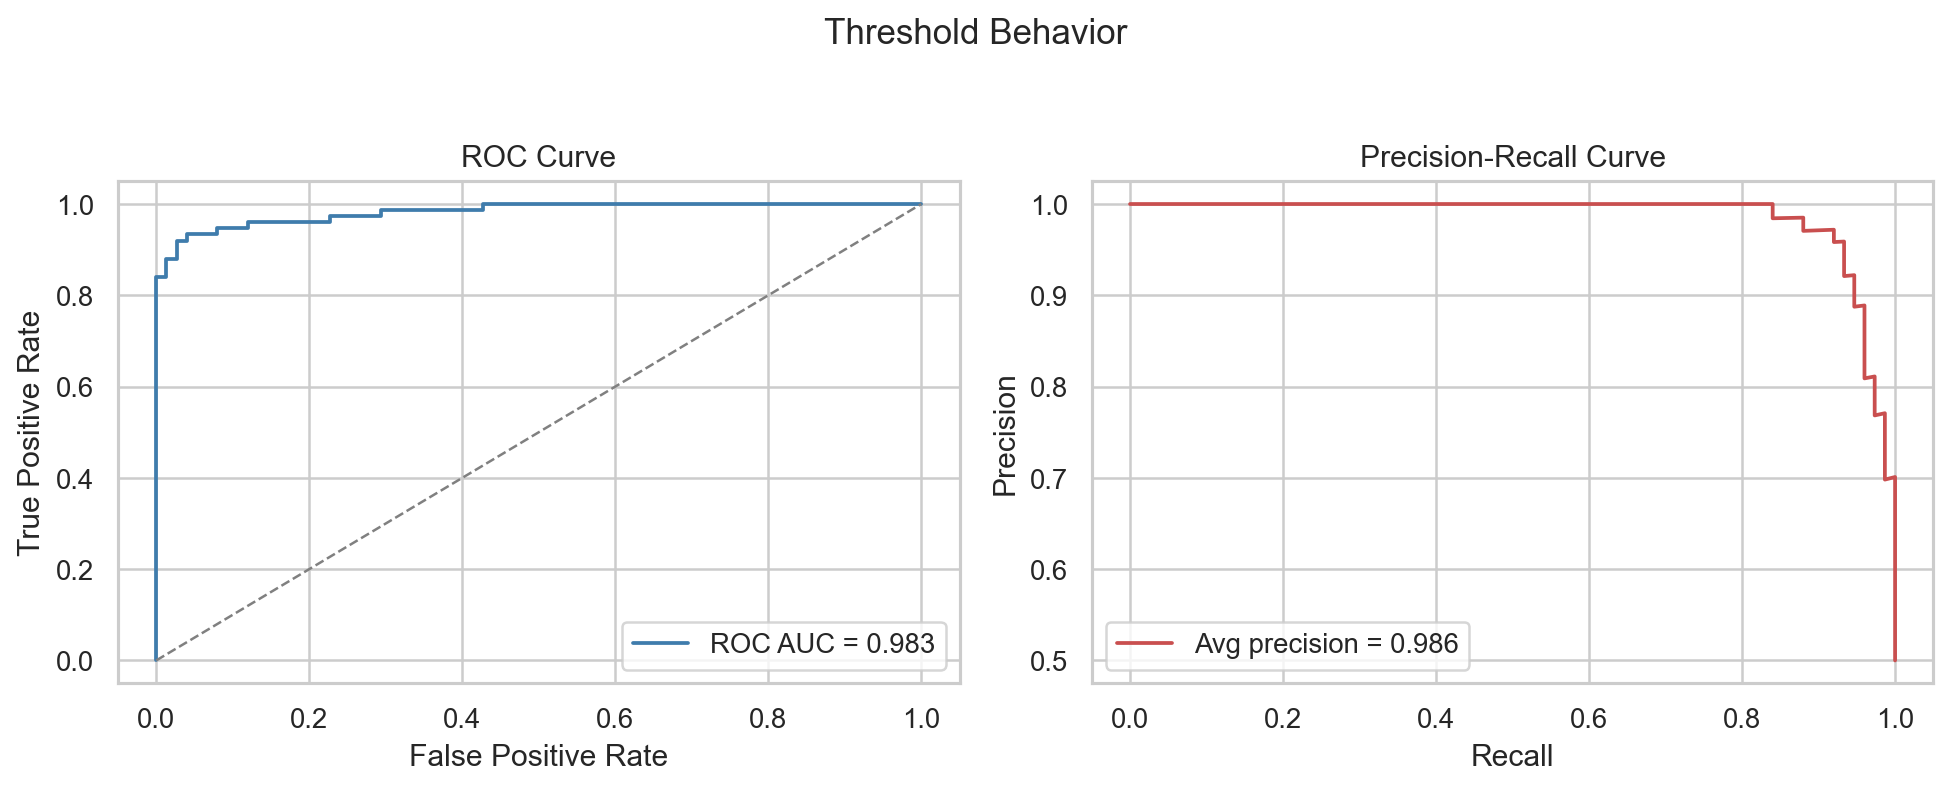

In [132]:
fpr, tpr, _ = roc_curve(y_true, test_probs)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(fpr, tpr, color="#3f7cac", label=f"ROC AUC = {metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(recall_curve, precision_curve, color="#c94f4f", label=f"Avg precision = {metrics['average_precision']:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

fig.suptitle("Threshold Behavior", y=1.04, fontsize=14)
fig.tight_layout()
show_figure(fig)



## Error Analysis


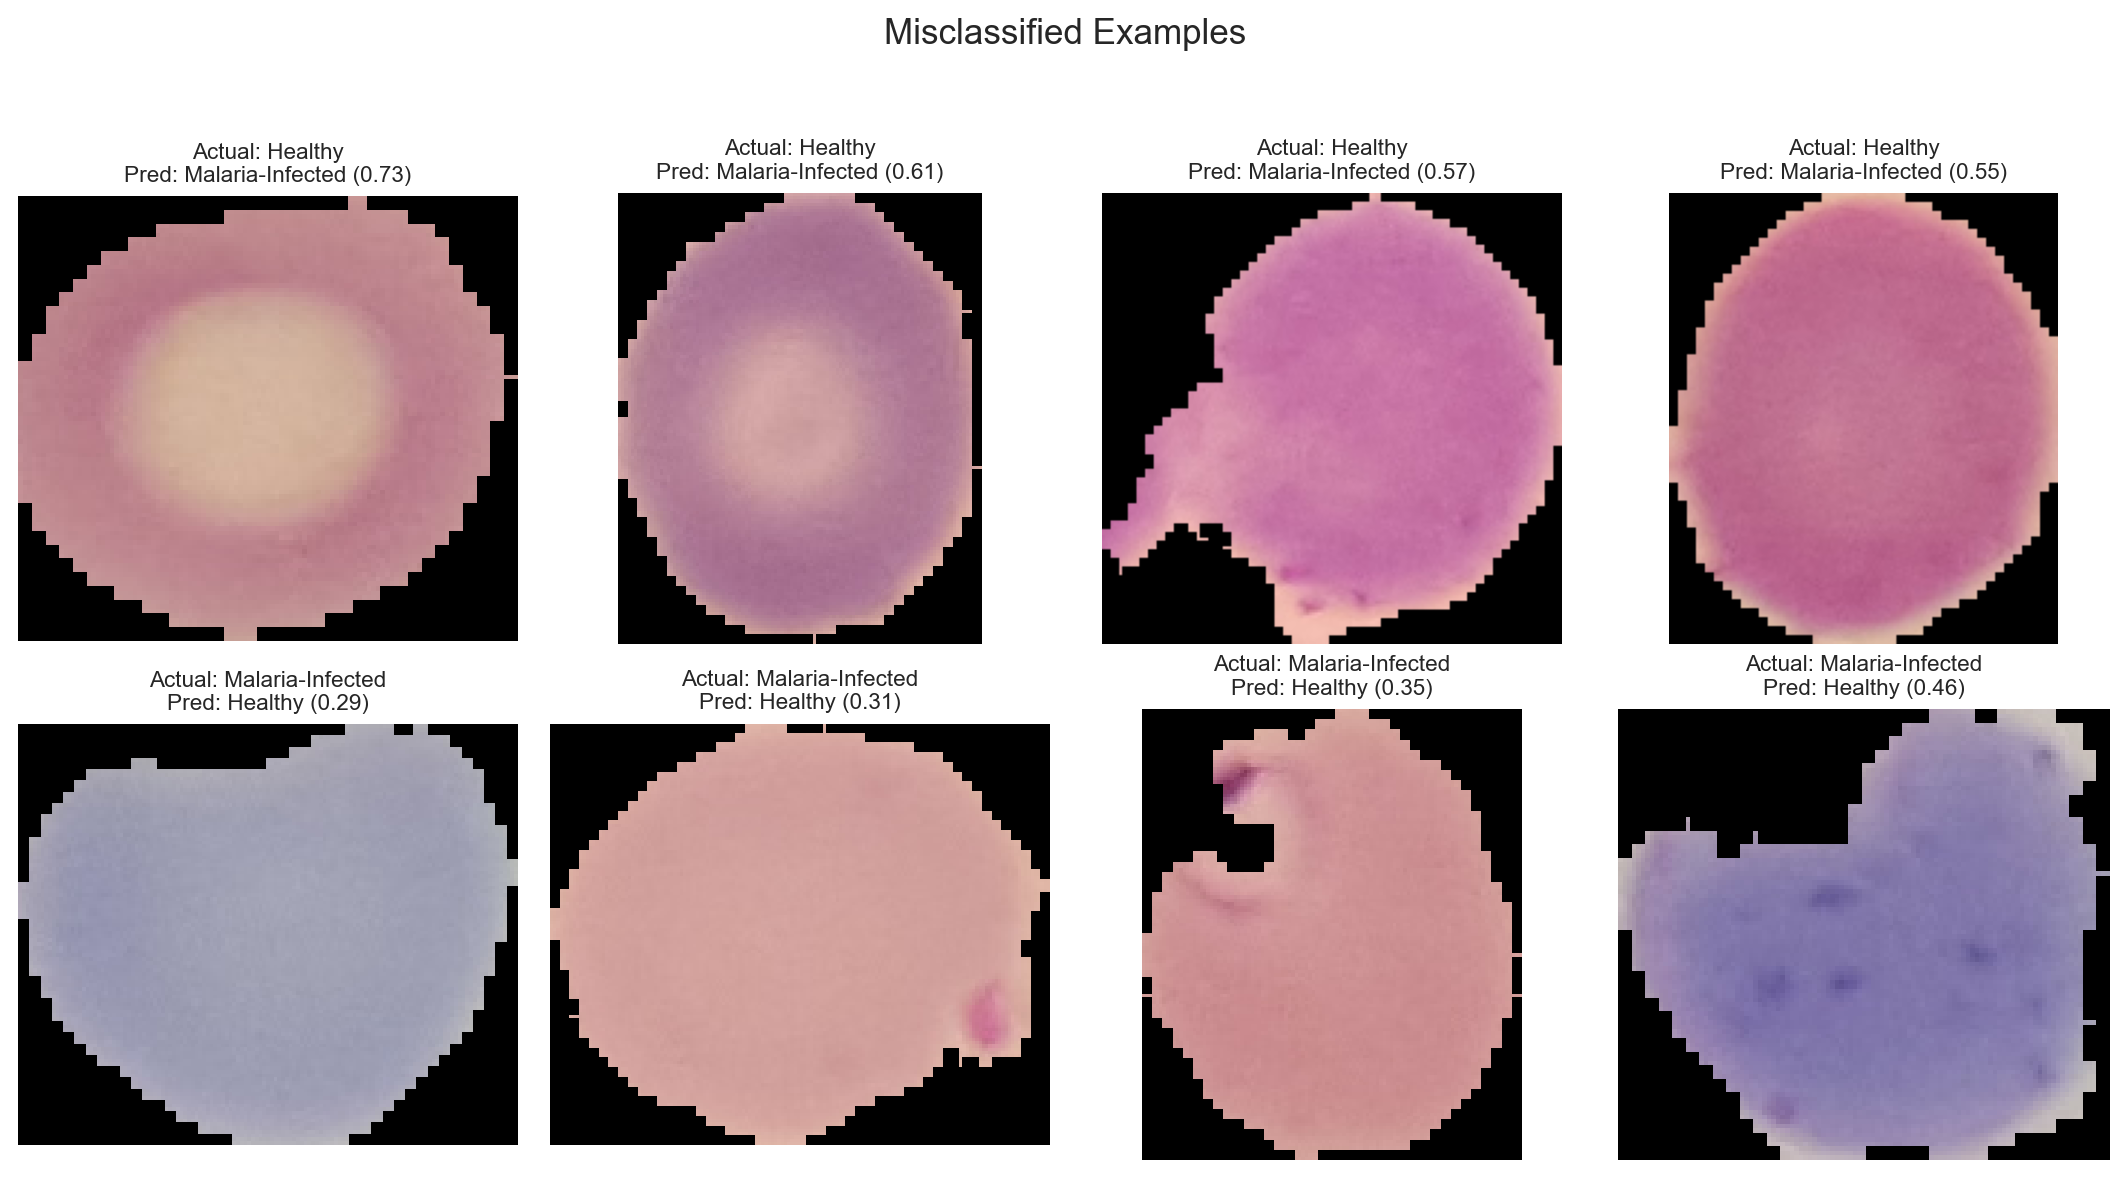

,label_name,pred_name,count
0,Healthy,Healthy,69
1,Healthy,Malaria-Infected,6
2,Malaria-Infected,Healthy,4
3,Malaria-Infected,Malaria-Infected,71


In [133]:
error_df = test_df.copy().reset_index(drop=True)
error_df["prob_infected"] = test_probs
error_df["pred_label"] = y_pred
error_df["pred_name"] = error_df["pred_label"].map(LABEL_NAMES)
error_df["correct"] = error_df["label"] == error_df["pred_label"]
error_df["uncertainty"] = np.abs(error_df["prob_infected"] - 0.50)

false_positive = error_df[(error_df["label"] == 0) & (error_df["pred_label"] == 1)].sort_values("prob_infected", ascending=False).head(4)
false_negative = error_df[(error_df["label"] == 1) & (error_df["pred_label"] == 0)].sort_values("prob_infected", ascending=True).head(4)

examples = pd.concat([false_positive, false_negative]).head(8)
title = "Misclassified Examples"
if examples.empty:
    examples = error_df.sort_values("uncertainty").head(8)
    title = "Most Uncertain Correct Examples"

cols = 4
rows = math.ceil(len(examples) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.2 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, examples.iterrows()):
    with Image.open(row["path"]) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(
        f"Actual: {row['label_name']}\nPred: {row['pred_name']} ({row['prob_infected']:.2f})",
        fontsize=9,
    )
    ax.axis("off")
for ax in axes[len(examples):]:
    ax.axis("off")

fig.suptitle(title, y=1.02, fontsize=14)
fig.tight_layout()
show_figure(fig)

display(error_df.groupby(["label_name", "pred_name"]).size().rename("count").reset_index())


## Grad-CAM Interpretability


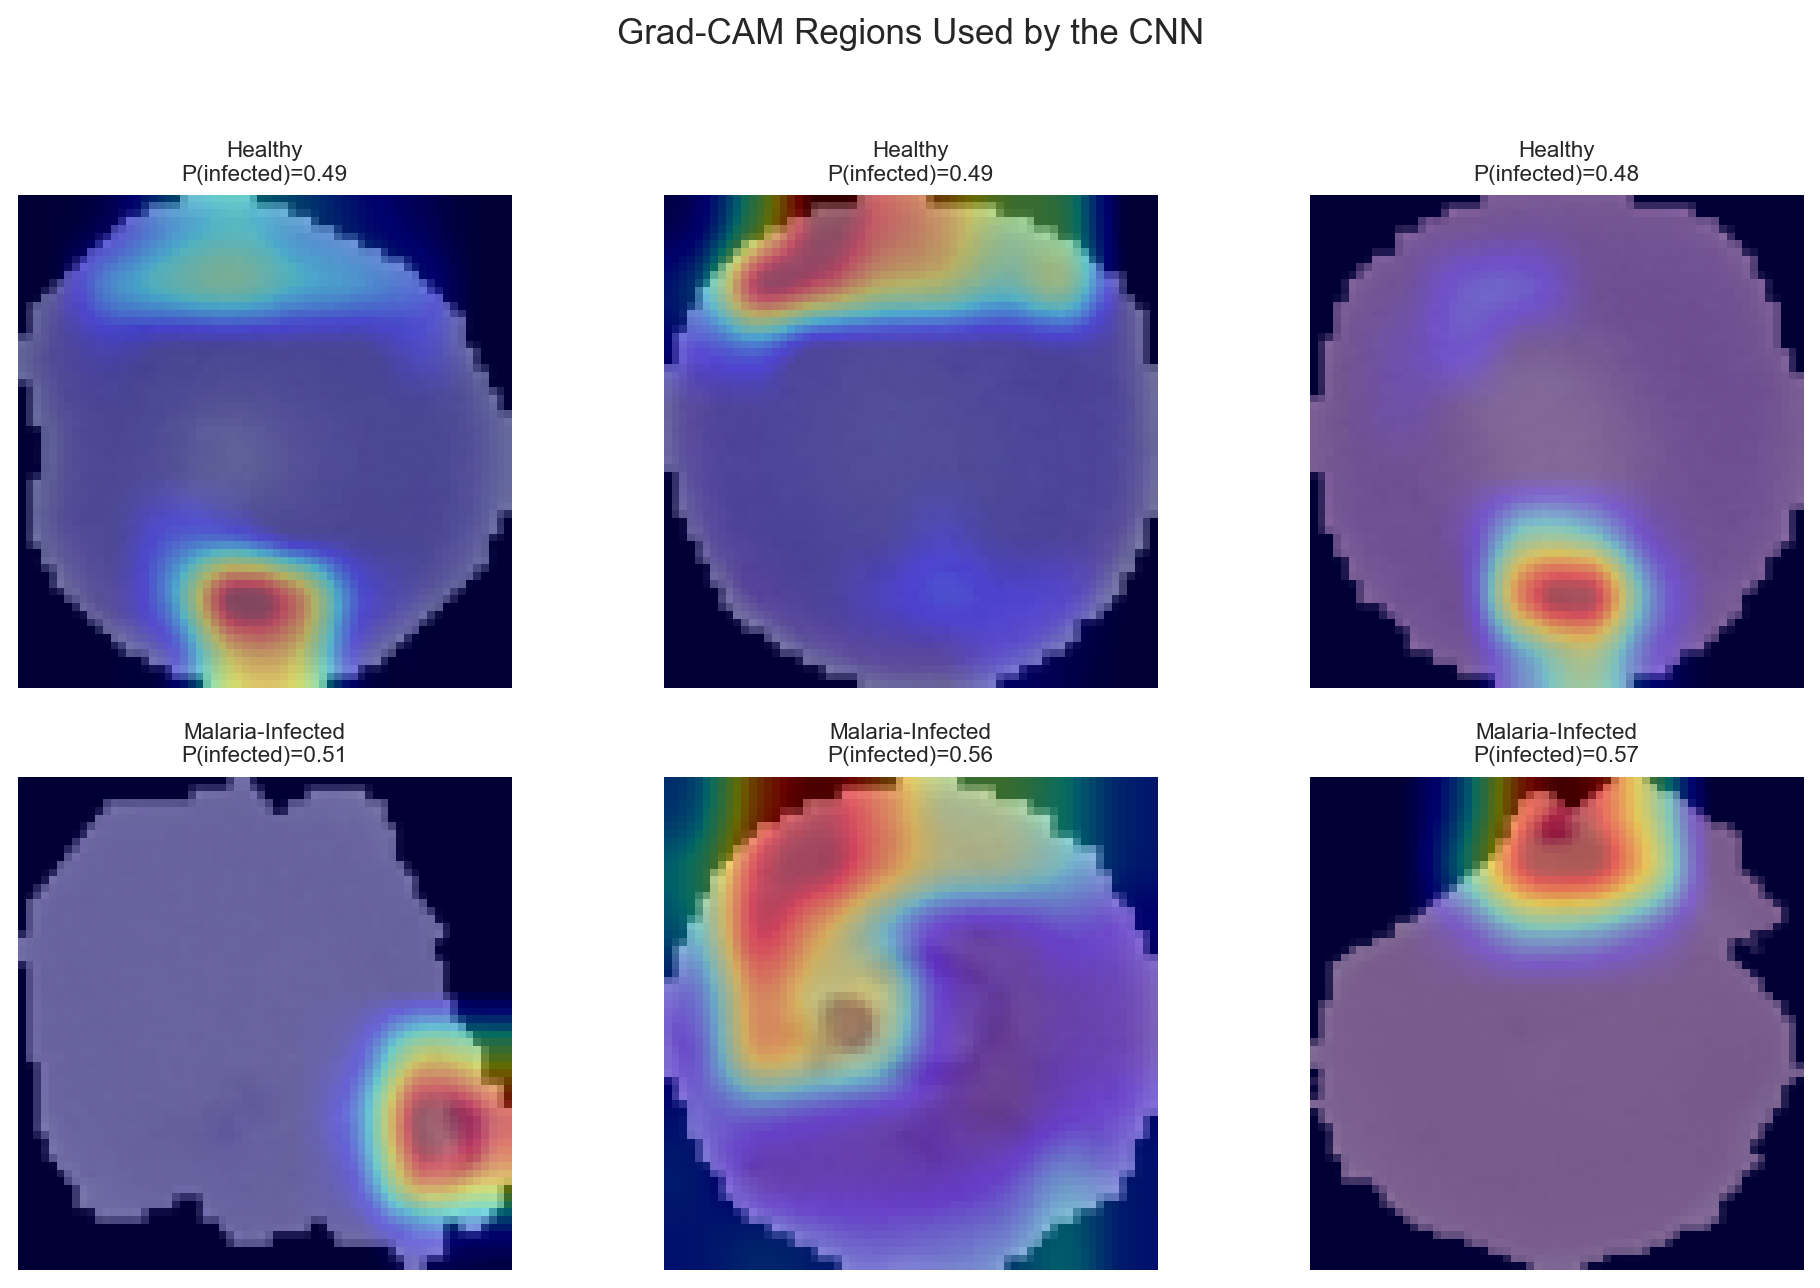

In [134]:
def image_array_for_path(path):
    with Image.open(path) as img:
        pil_image = img.convert("RGB").resize(IMG_SIZE)
    tensor = transforms.ToTensor()(pil_image)
    return tensor, np.asarray(pil_image, dtype=np.float32) / 255.0


def make_gradcam_heatmap(img_tensor, trained_model):
    trained_model.eval()
    activations = {}
    gradients = {}

    def forward_hook(module, inputs, output):
        activations["value"] = output.detach()

    def backward_hook(module, grad_input, grad_output):
        gradients["value"] = grad_output[0].detach()

    forward_handle = trained_model.last_relu.register_forward_hook(forward_hook)
    backward_handle = trained_model.last_relu.register_full_backward_hook(backward_hook)

    trained_model.zero_grad()
    logits = trained_model(img_tensor.unsqueeze(0).to(DEVICE))
    score = logits[0]
    score.backward()

    forward_handle.remove()
    backward_handle.remove()

    activation = activations["value"][0].cpu()
    gradient = gradients["value"][0].cpu()
    weights = gradient.mean(dim=(1, 2), keepdim=True)
    heatmap = (weights * activation).sum(dim=0)
    heatmap = torch.relu(heatmap)
    max_value = heatmap.max()
    if max_value > 0:
        heatmap = heatmap / max_value
    return heatmap.numpy()


def overlay_heatmap(original_array, heatmap, alpha=0.42):
    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE)
    heatmap_resized = np.asarray(heatmap_resized, dtype=np.float32) / 255.0
    cmap = plt.get_cmap("jet")
    colored_heatmap = cmap(heatmap_resized)[..., :3]
    overlay = (1 - alpha) * original_array + alpha * colored_heatmap
    return np.clip(overlay, 0, 1)


correct_examples = error_df[error_df["correct"]].copy()
gradcam_examples = (
    correct_examples.groupby("label", group_keys=False)
    .apply(lambda x: x.sort_values("uncertainty").head(3))
    .reset_index(drop=True)
)
if len(gradcam_examples) < 6:
    gradcam_examples = error_df.sort_values("uncertainty").head(6)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.ravel()

for ax, (_, row) in zip(axes, gradcam_examples.head(6).iterrows()):
    img_tensor, original_array = image_array_for_path(row["path"])
    heatmap = make_gradcam_heatmap(img_tensor, model)
    overlay = overlay_heatmap(original_array, heatmap)
    ax.imshow(overlay)
    ax.set_title(
        f"{row['label_name']}\nP(infected)={row['prob_infected']:.2f}",
        fontsize=9,
    )
    ax.axis("off")
for ax in axes[len(gradcam_examples.head(6)):]:
    ax.axis("off")

fig.suptitle("Grad-CAM Regions Used by the CNN", y=1.02, fontsize=14)
fig.tight_layout()
show_figure(fig)



# 8. Improvement Suggestions


In [135]:
final_summary = pd.DataFrame(
    [
        ("Images used in this run", f"{len(working_df):,}"),
        ("Test images", f"{len(test_df):,}"),
        ("Accuracy", f"{metrics['accuracy']:.3f}"),
        ("Precision", f"{metrics['precision']:.3f}"),
        ("Recall", f"{metrics['recall']:.3f}"),
        ("F1-score", f"{metrics['f1_score']:.3f}"),
        ("ROC AUC", f"{metrics['roc_auc']:.3f}"),
        ("Notebook figure outputs", "12 inline figures"),
    ],
    columns=["item", "value"],
)
display(final_summary)

print("Suggested next improvements:")
print("- Set FAST_RUN = False for full-dataset training if enough time is available.")
print("- Use a patient-level holdout split for stronger medical validation.")
print("- Add stain normalization if images come from multiple microscopes or labs.")
print("- Ask a domain expert to review Grad-CAM overlays for biologically plausible focus regions.")


,item,value
0,Images used in this run,"1,000"
1,Test images,150
2,Accuracy,0.933
3,Precision,0.922
4,Recall,0.947
5,F1-score,0.934
6,ROC AUC,0.983
7,Notebook figure outputs,12 inline figures


Suggested next improvements:
- Set FAST_RUN = False for full-dataset training if enough time is available.
- Use a patient-level holdout split for stronger medical validation.
- Add stain normalization if images come from multiple microscopes or labs.
- Ask a domain expert to review Grad-CAM overlays for biologically plausible focus regions.
